In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PAOFLOW import PAOFLOW

In [ ]:
paoflow = PAOFLOW.PAOFLOW(savedir='./silicon.save/', model=None, outputdir='./output/', 
                          smearing=None, verbose=True)


#############################################################################################
#                                                                                           #
#                                          PAOFLOW                                          #
#                                                                                           #
#                  Utility to construct and operate on Hamiltonians from                    #
#                 the Projections of DFT wfc on Atomic Orbital bases (PAO)                  #
#                                                                                           #
#                       (c)2016-2024 ERMES group (http://ermes.unt.edu)                     #
#############################################################################################

Monkhorst and Pack grid: 12 12 12 0 0 0
Insulator: True
Magnetic: False
Number of kpoints: 72
Number of electrons: 8.000000
Number of bands: 18
SciPy wi

In [3]:
paoflow.jdos(delta=0.1, emin=0.0, emax=4.0, ne=801, jdos_smeartype='gauss')

Integration over JDOS =  0.020246492676535693
Joint density of states in:                 0.079 sec


In [ ]:
basis_path = '../../../PAOFLOW/BASIS/'
basis_config = {'Si':['3S','3P','3D','4S','4P']}

paoflow.projections(configuration=basis_config, basispath=basis_path, internal=True)
paoflow.projectability()
paoflow.pao_hamiltonian(expand_wedge=True)
paoflow.pao_eigh()
paoflow.gradient_and_momenta()
paoflow.dielectric_tensor(delta=0.1,emax=4.,ne=801,d_tensor="diag")

atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\3S.dat      tau: [0. 0. 0.]
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\3P.dat      tau: [0. 0. 0.]
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\3D.dat      tau: [0. 0. 0.]
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\4S.dat      tau: [0. 0. 0.]
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\4P.dat      tau: [0. 0. 0.]
      atwfc:   1  3S  l=0, m=1
      atwfc:   2  3P  l=1, m=1
      atwfc:   3  3P  l=1, m=2
      atwfc:   4  3P  l=1, m=3
      atwfc:   5  3D  l=2, m=1
      atwfc:   6  3D  l=2, m=2
      atwfc:   7  3D  l=2, m=3
      atwfc:   8  3D  l=2, m=4
      atwfc:   9  3D  l=2, m=5
      atwfc:  10  4S  l=0, m=1
      atwfc:  11  4P  l=1, m=1
      atwfc:  12  4P  l=1, m=2
      atwfc:  13  4P  l=1, m=3
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\3S.dat      tau: [2.6498695 2.6498695 2.6498695]
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\3P.dat      tau: [2.6498695 2.6498695 2.6498695]
atom: Si  AEWFC: ../PAOFLOW/BASIS/Si\3D.dat      tau: [2.6498695 2.6498695 2.6498695]
atom: Si  AEWF

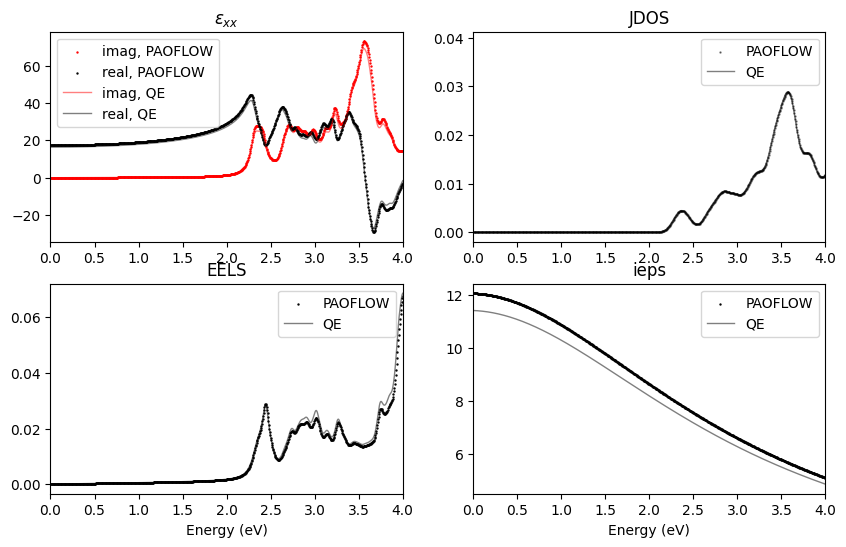

In [ ]:
# PAOFLOW output
epsi_xx = np.loadtxt('./output/epsi_xx.dat')
epsr_xx = np.loadtxt('./output/epsr_xx.dat')
jdos = np.loadtxt('./output/jdos.dat')
eels_xx = np.loadtxt('./output/eels_xx.dat')
ieps_xx = np.loadtxt('./output/ieps_xx.dat')
# QE output
epsiqe = np.loadtxt('./QE_reference/epsi_silicon.dat')
epsrqe = np.loadtxt('./QE_reference/epsr_silicon.dat')
jdosqe = np.loadtxt('./QE_reference/jdos_silicon.dat')
eelsqe = np.loadtxt('./QE_reference/eels_silicon.dat')
iepsqe = np.loadtxt('./QE_reference/ieps_silicon.dat')
fig, ax = plt.subplots(2,2,figsize=(10,6))

ax[0,0].scatter(epsi_xx[:,0],epsi_xx[:,1],color='red',s=0.5,label="imag, PAOFLOW")
ax[0,0].scatter(epsr_xx[:,0],epsr_xx[:,1],color='black',s=0.5,label="real, PAOFLOW")
ax[0,0].plot(epsiqe[:,0],epsiqe[:,1],color='red',alpha=0.5,label="imag, QE",linewidth=1)
ax[0,0].plot(epsrqe[:,0],epsrqe[:,1],color='black',alpha=0.5,label="real, QE",linewidth=1)
ax[0,0].set_xlim([0,4])
ax[0,0].set_title("$\epsilon_{xx}$")
ax[0,0].legend()

ax[0,1].scatter(jdos[:,0],jdos[:,1],color='k',s=0.5,label="PAOFLOW",alpha=0.5)
ax[0,1].plot(jdosqe[:,0],jdosqe[:,1],color='k',alpha=0.5,label="QE",linewidth=1)
ax[0,1].set_xlim([0,4])
ax[0,1].set_title("JDOS")
ax[0,1].legend()

ax[1,0].scatter(eels_xx[:,0],eels_xx[:,1],color='k',s=0.5,label="PAOFLOW")
ax[1,0].plot(eelsqe[:,0],eelsqe[:,1],color='k',alpha=0.5,label="QE",linewidth=1)
ax[1,0].set_xlim([0,4])
ax[1,0].set_title("EELS")
ax[1,0].set_xlabel("Energy (eV)")
ax[1,0].legend()

ax[1,1].scatter(ieps_xx[:,0],ieps_xx[:,1],color='k',s=0.5,label="PAOFLOW")
ax[1,1].plot(iepsqe[:,0],iepsqe[:,1],color='k',alpha=0.5,label="QE",linewidth=1)
ax[1,1].set_xlim([0,4])
ax[1,1].set_title("ieps")
ax[1,1].set_xlabel("Energy (eV)")
ax[1,1].legend()
plt.show()